# Регрессионный анализ датасета зарплат

In [1]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv("Salary_dataset.csv")
print("Размер таблицы:", df.shape)
df.info()

Размер таблицы: (30, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


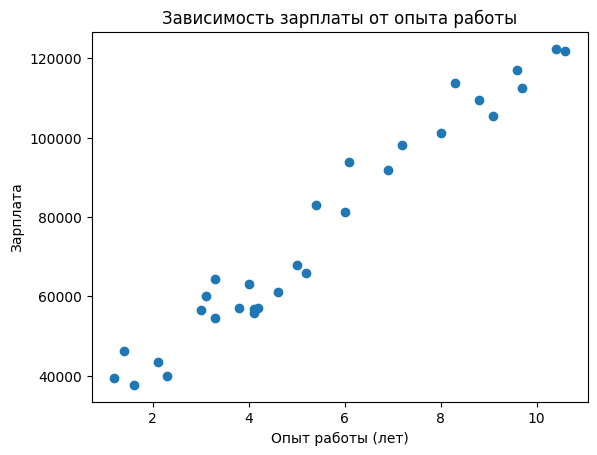

In [27]:
plt.scatter(df["YearsExperience"], df["Salary"])
plt.title("Зависимость зарплаты от опыта работы")
plt.xlabel("Опыт работы (лет)")
plt.ylabel("Зарплата")
plt.show()

На графике сразу видна значительная взаимосвязь между двумя переменными. <br>
Построим прямую $y = b_0 + b_1 \cdot x$, где y - зарплата, а x - опыт работы.

In [28]:
corr = df[["YearsExperience", "Salary"]].corr().iloc[0, 1]
print(f"Коэффициент корреляции: {corr:.3f}")
b1 = corr * np.std(df["Salary"]) / np.std(df["YearsExperience"])
b0 = np.mean(df["Salary"]) - b1 * np.mean(df["YearsExperience"])
print(f"y = {b0:.2f} + {b1:.2f} * x")
y = b0 + b1 * df["YearsExperience"]

Коэффициент корреляции: 0.978
y = 24848.20 + 9449.96 * x


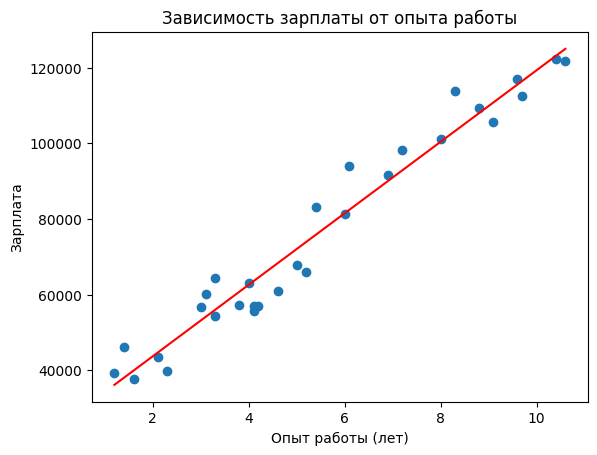

In [29]:
plt.scatter(df["YearsExperience"], df["Salary"])
plt.plot(df["YearsExperience"], y, color='red')
plt.title("Зависимость зарплаты от опыта работы")
plt.xlabel("Опыт работы (лет)")
plt.ylabel("Зарплата")
plt.show()

Проверим статистическую значимость взаимосвязи. Пусть гипотезы: <br>
$H_0: b_1 = 0$ <br>
$H_1: b_1 \ne 0$

In [38]:
degf = df.shape[0] - 2

SSY = np.sum((df["Salary"] - y)**2)
SSX = np.sum((df["YearsExperience"] - df["YearsExperience"].mean())**2)
SE = np.sqrt(SSY / (SSX * degf))

t = b1 / SE
p_value = 2 * (1 - stats.t.cdf(abs(t), df=degf))
alpha = 0.05
print(f"p-value: {p_value:.4f}")
if p_value < alpha:
  print("Тест стат. значим, отклоняем нулевую гипотезу")
else:
  print("Тест не стат. значим")

p-value: 0.0000
Тест стат. значим, отклоняем нулевую гипотезу


In [40]:
r_squared = corr**2
print("Коэффициент детерминации:", r_squared)

Коэффициент детерминации: 0.9569566641435087


Проверим полученные значения с помощью метода linregress библиотеки scipy:

In [42]:
b1_check, b0_check, r_check, p_check, se_check = stats.linregress(df["YearsExperience"], df["Salary"])
print(f"Прямая: y =  {b0_check:.2f} + {b1_check:.2f} * x")
print(f"Коэф. детерминации: {r_check**2:.3f}")
print(f"p-значение: {p_check:.4f}")
print(f"ст. ошибка: {se_check:.4f} (ранее получена: {SE:.4f})")

Прямая: y =  24848.20 + 9449.96 * x
Коэф. детерминации: 0.957
p-значение: 0.0000
ст. ошибка: 378.7546 (ранее получена: 378.7546)


Значения совпали с полученными ранее.

Получаем, что зарплата и опыт работы в данном датасете действительно **взаимосвязаны**.

Коэффициент детерминации $R^2 = 0.96$.